#Assessment Lab — Implementing the Perceptron Algorithm using PySpark on the Spambase Dataset
In this assessment lab, you will independently implement the Perceptron algorithm
using PySpark to classify email messages as either spam or non-spam (ham) based
on numerical features extracted from the content of each email. Building on the
Guided Lab, you must adapt the same Spark-based workflow to the Spambase
Dataset, which contains numerical attributes representing the frequency of specific
words, characters, and capital letter sequences within email messages. The task
requires you to load the dataset into a Spark DataFrame, prepare the numerical
features, and implement the Perceptron learning algorithm to perform binary
classification.
You must implement the complete workflow, including data loading, data exploration,
feature vector assembly, feature scaling where appropriate, model training,
prediction, and evaluation. Since the dataset differs from the Guided Lab, you are
required to adapt the data preparation process accordingly. The implemented model
should be evaluated using appropriate metrics such as accuracy, precision, recall,
and F1-score, and the results should be analysed to assess classification
performance. The objective is to demonstrate your ability to implement a
fundamental supervised learning algorithm using PySpark and adapt an existing
machine learning workflow to a different real-world dataset.
#Dataset Description
The Spambase Dataset1 consists of email messages represented by 57 continuous
numerical attributes that describe the frequency of selected words, characters, and
sequences of capital letters commonly found in email content. Each record is
assigned a binary class label indicating whether the email is classified as spam or
non-spam (ham).
The dataset contains the following classes:
1. Non-Spam (Ham)
2. Spam
This is a binary classification problem widely used for evaluating supervised machine
learning algorithms in email filtering and text classification.

In [30]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF, StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
#Create a Spark session

spark = (
    SparkSession.builder
    .appName("Perceptron_MSc_Guided_Lab")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.3


In [20]:
DATA_PATH = '/content/emails.csv'

pdf = pd.read_csv(DATA_PATH)
required = {"text","spam"}
if not required.issubset(pdf.columns):
    raise ValueError(f"Expected columns {required}, found {set(pdf.columns)}")

pdf["text"] = pdf["text"].fillna("").astype(str)
pdf["spam"] = pdf["spam"].astype(int)
df = spark.createDataFrame(pdf)

print("Rows:", df.count())
print("Columns:", df.columns)
df.show()

Rows: 5728
Columns: ['text', 'spam']
+--------------------+----+
|                text|spam|
+--------------------+----+
|Subject: naturall...|   1|
|Subject: the stoc...|   1|
|Subject: unbeliev...|   1|
|Subject: 4 color ...|   1|
|Subject: do not h...|   1|
|Subject: great nn...|   1|
|Subject: here ' s...|   1|
|Subject: save you...|   1|
|Subject: undelive...|   1|
|Subject: save you...|   1|
|Subject: las vega...|   1|
|Subject: save you...|   1|
|Subject: brighten...|   1|
|Subject: wall str...|   1|
|Subject: fpa noti...|   1|
|Subject: search e...|   1|
|Subject: only our...|   1|
|Subject: localize...|   1|
|Subject: security...|   1|
|Subject: 21 st ce...|   1|
+--------------------+----+
only showing top 20 rows


In [21]:
df.printSchema()
print("Shape:", df.count(), "rows x", len(df.columns), "columns")
print("\nClass distribution:")
df.groupBy("spam").count().orderBy("spam").show()

print("Missing text:", df.filter(col("text").isNull()).count())
print("Missing labels:", df.filter(col("spam").isNull()).count())

root
 |-- text: string (nullable = true)
 |-- spam: long (nullable = true)

Shape: 5728 rows x 2 columns

Class distribution:
+----+-----+
|spam|count|
+----+-----+
|   0| 4360|
|   1| 1368|
+----+-----+

Missing text: 0
Missing labels: 0


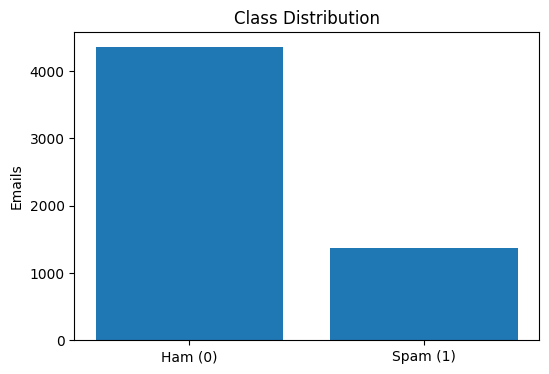

   spam  count
0     0   4360
1     1   1368


In [23]:
class_pd = df.groupBy("spam").count().orderBy("spam").toPandas()
plt.figure(figsize=(6,4))
plt.bar(["Ham (0)","Spam (1)"], class_pd["count"])
plt.title("Class Distribution")
plt.ylabel("Emails")
plt.show()
print(class_pd)

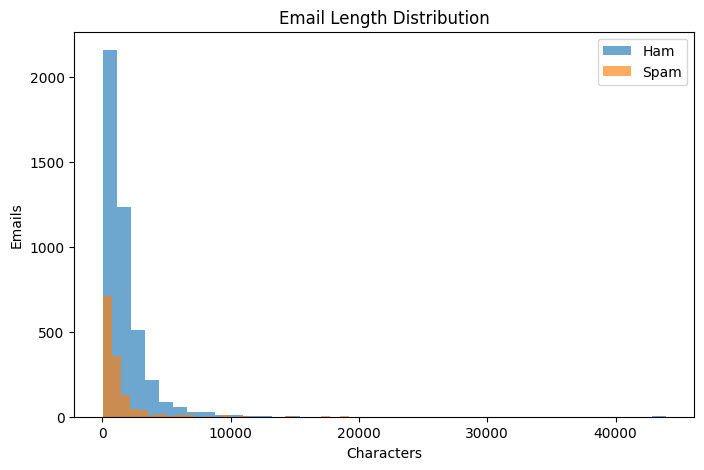

       count         mean          std   min     25%     50%      75%      max
spam                                                                          
0     4360.0  1631.918119  1959.664549  13.0  577.75  1122.0  2037.25  43952.0
1     1368.0  1317.257310  2271.372893  18.0  401.50   693.5  1250.25  28432.0


In [27]:
from pyspark.sql.functions import length

length_pd = df.withColumn("email_length", length(col("text"))).select("spam","email_length").toPandas()
plt.figure(figsize=(8,5))
plt.hist(length_pd[length_pd.spam==0].email_length, bins=40, alpha=.65, label="Ham")
plt.hist(length_pd[length_pd.spam==1].email_length, bins=40, alpha=.65, label="Spam")
plt.title("Email Length Distribution")
plt.xlabel("Characters"); plt.ylabel("Emails"); plt.legend(); plt.show()
print(length_pd.groupby("spam").email_length.describe())

In [28]:
train_raw, test_raw = df.randomSplit([.80,.20], seed=RANDOM_STATE)
train_raw, test_raw = train_raw.cache(), test_raw.cache()
print("Training:", train_raw.count())
print("Test    :", test_raw.count())
print("Total   :", train_raw.count()+test_raw.count())
print("\nTraining labels"); train_raw.groupBy("spam").count().orderBy("spam").show()
print("Test labels"); test_raw.groupBy("spam").count().orderBy("spam").show()

Training: 4648
Test    : 1080
Total   : 5728

Training labels
+----+-----+
|spam|count|
+----+-----+
|   0| 3531|
|   1| 1117|
+----+-----+

Test labels
+----+-----+
|spam|count|
+----+-----+
|   0|  829|
|   1|  251|
+----+-----+



In [31]:
tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern="\\W+", gaps=True, toLowercase=True)
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")

train_tokens = remover.transform(tokenizer.transform(train_raw))
test_tokens = remover.transform(tokenizer.transform(test_raw))

train_tokens.select("text","filtered_tokens").show(3, truncate=120)

+------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+
|                                                                                                                    text|                                                                                                         filtered_tokens|
+------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+
|Subject:   http : / / www . virtu  ally - anywhere . com / sports /  hello ,  i was hoping you could help me . the li...|[subject, http, www, virtu, ally, anywhere, com, sports, hello, hoping, help, link, takes, several, facility, stadium...|
|Subject: ! gorgeous , c

In [32]:
cv = CountVectorizer(inputCol="filtered_tokens", outputCol="rawFeatures", vocabSize=5000, minDF=2.0)
cv_model = cv.fit(train_tokens)

train_counts = cv_model.transform(train_tokens)
test_counts = cv_model.transform(test_tokens)

print("Vocabulary size:", len(cv_model.vocabulary))
print("First 30 terms:", cv_model.vocabulary[:30])
train_counts.select("rawFeatures","spam").show(3, truncate=False)

Vocabulary size: 5000
First 30 terms: ['_', 'enron', 'ect', 'subject', 'vince', 'hou', 'com', 'please', '2000', 'kaminski', 're', 'cc', 'j', 'pm', '1', '2001', '2', 'research', 'time', 'thanks', '10', 'may', 'know', '3', 'group', 'new', 'e', 'information', 'like', 'risk']
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+
|rawFeatures                     

In [33]:
idf = IDF(inputCol="rawFeatures", outputCol="tfidfFeatures")
idf_model = idf.fit(train_counts)

train_tfidf = idf_model.transform(train_counts)
test_tfidf = idf_model.transform(test_counts)

scaler = StandardScaler(inputCol="tfidfFeatures", outputCol="scaledFeatures",
                        withMean=False, withStd=True)
scaler_model = scaler.fit(train_tfidf)

train_features = scaler_model.transform(train_tfidf)
test_features = scaler_model.transform(test_tfidf)

train_features.select("scaledFeatures","spam").show(3, truncate=False)
print("Feature extraction and scaling completed.")

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [34]:
train_pd = train_features.select("scaledFeatures","spam").toPandas()
test_pd = test_features.select("scaledFeatures","spam").toPandas()

X_train = np.vstack(train_pd.scaledFeatures.map(lambda v: v.toArray()).values)
X_test = np.vstack(test_pd.scaledFeatures.map(lambda v: v.toArray()).values)
y_train = train_pd.spam.to_numpy(dtype=int)
y_test = test_pd.spam.to_numpy(dtype=int)

y_train_pm = np.where(y_train==1, 1, -1)
y_test_pm = np.where(y_test==1, 1, -1)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Spam training examples:", int((y_train==1).sum()))
print("Ham training examples :", int((y_train==0).sum()))

X_train: (4648, 5000)
X_test : (1080, 5000)
Spam training examples: 1117
Ham training examples : 3531


In [35]:
class ManualPerceptron:
    def __init__(self, learning_rate=.01, epochs=50, shuffle=True, random_state=42):
        self.learning_rate=learning_rate; self.epochs=epochs
        self.shuffle=shuffle; self.random_state=random_state

    @staticmethod
    def activation(score):
        return np.where(score>=0, 1, -1)

    def fit(self, X, y):
        X=np.asarray(X,dtype=float); y=np.asarray(y,dtype=int)
        if set(np.unique(y)) - {-1,1}: raise ValueError("Labels must be -1/+1.")
        rng=np.random.default_rng(self.random_state)
        self.weights_=np.zeros(X.shape[1]); self.bias_=0.
        self.errors_per_epoch_=[]; self.weights_history_=[]; self.bias_history_=[]
        self.best_errors_=np.inf; self.best_weights_=self.weights_.copy()
        self.best_bias_=0.; self.best_epoch_=0; self.converged_=False

        for epoch in range(self.epochs):
            idx=np.arange(len(X))
            if self.shuffle: rng.shuffle(idx)
            errors=0
            for i in idx:
                score=np.dot(X[i],self.weights_)+self.bias_
                pred=1 if score>=0 else -1
                if pred != y[i]:
                    update=self.learning_rate*y[i]
                    self.weights_ += update*X[i]
                    self.bias_ += update
                    errors += 1
            self.errors_per_epoch_.append(errors)
            self.weights_history_.append(self.weights_.copy())
            self.bias_history_.append(self.bias_)
            if errors < self.best_errors_:
                self.best_errors_=errors
                self.best_weights_=self.weights_.copy()
                self.best_bias_=self.bias_
                self.best_epoch_=epoch+1
            if errors==0:
                self.converged_=True; break
        self.weights_history_=np.asarray(self.weights_history_)
        self.bias_history_=np.asarray(self.bias_history_)
        return self

    def decision_function(self,X,use_pocket=False):
        w=self.best_weights_ if use_pocket else self.weights_
        b=self.best_bias_ if use_pocket else self.bias_
        return np.asarray(X)@w+b

    def predict(self,X,use_pocket=False):
        return self.activation(self.decision_function(X,use_pocket))

model=ManualPerceptron(learning_rate=.01, epochs=50, shuffle=True, random_state=RANDOM_STATE)
model.fit(X_train,y_train_pm)

print("Epochs:",len(model.errors_per_epoch_))
print("Converged:",model.converged_)
print("Best training errors:",model.best_errors_)
print("Best epoch:",model.best_epoch_)
print("Features:",len(model.weights_))

Epochs: 32
Converged: True
Best training errors: 0
Best epoch: 32
Features: 5000


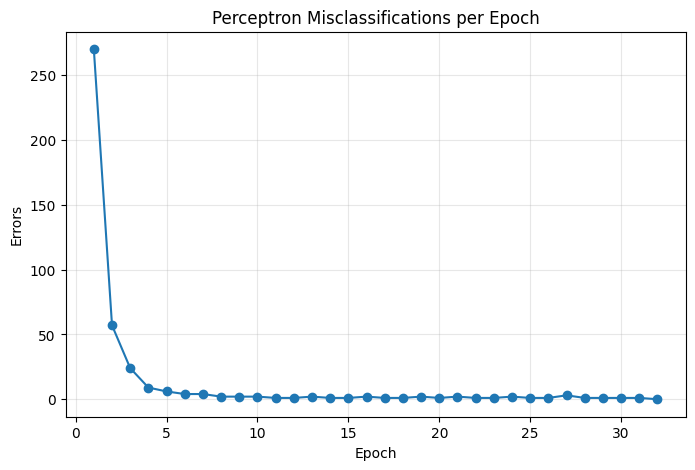

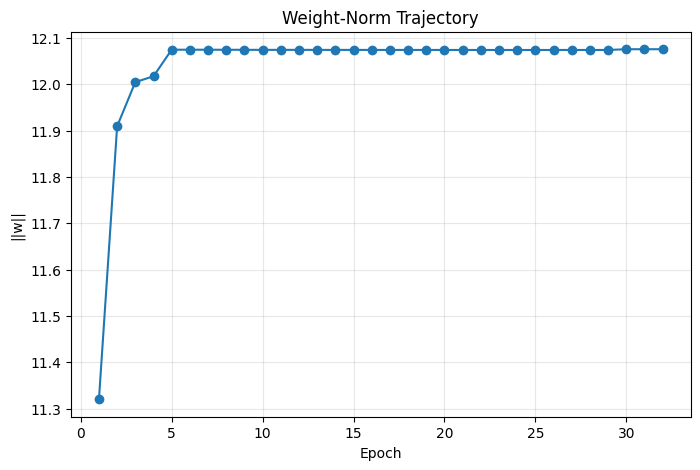

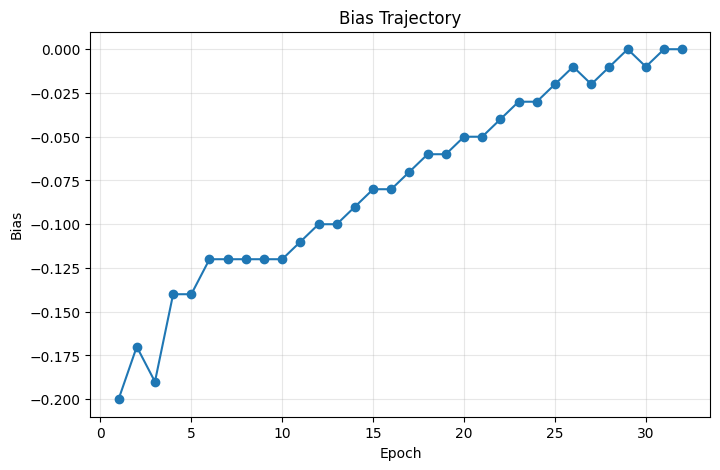

In [36]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(model.errors_per_epoch_)+1),model.errors_per_epoch_,marker="o")
plt.title("Perceptron Misclassifications per Epoch")
plt.xlabel("Epoch"); plt.ylabel("Errors"); plt.grid(alpha=.3); plt.show()

weight_norms=np.linalg.norm(model.weights_history_,axis=1)
plt.figure(figsize=(8,5))
plt.plot(range(1,len(weight_norms)+1),weight_norms,marker="o")
plt.title("Weight-Norm Trajectory"); plt.xlabel("Epoch"); plt.ylabel("||w||")
plt.grid(alpha=.3); plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1,len(model.bias_history_)+1),model.bias_history_,marker="o")
plt.title("Bias Trajectory"); plt.xlabel("Epoch"); plt.ylabel("Bias")
plt.grid(alpha=.3); plt.show()

In [37]:
y_pred_pocket_pm=model.predict(X_test,use_pocket=True)
y_pred_final_pm=model.predict(X_test,use_pocket=False)
y_pred_pocket=np.where(y_pred_pocket_pm==1,1,0)
y_pred_final=np.where(y_pred_final_pm==1,1,0)

def metric_summary(y_true,y_pred):
    return {
        "Accuracy":accuracy_score(y_true,y_pred),
        "Precision":precision_score(y_true,y_pred,zero_division=0),
        "Recall":recall_score(y_true,y_pred,zero_division=0),
        "F1-score":f1_score(y_true,y_pred,zero_division=0)
    }

pocket_metrics=metric_summary(y_test,y_pred_pocket)
final_metrics=metric_summary(y_test,y_pred_final)

print("Pocket model:")
print(pd.Series(pocket_metrics).round(4))
print("\nFinal epoch:")
print(pd.Series(final_metrics).round(4))

print("\nFirst 15 predictions:")
print(pd.DataFrame({"Actual":y_test[:15],"Predicted":y_pred_pocket[:15]}).to_string(index=False))

Pocket model:
Accuracy     0.9722
Precision    0.9333
Recall       0.9482
F1-score     0.9407
dtype: float64

Final epoch:
Accuracy     0.9722
Precision    0.9333
Recall       0.9482
F1-score     0.9407
dtype: float64

First 15 predictions:
 Actual  Predicted
      1          1
      1          1
      1          1
      1          1
      1          1
      1          1
      1          1
      0          0
      0          0
      1          1
      1          1
      1          1
      1          1
      1          1
      0          0


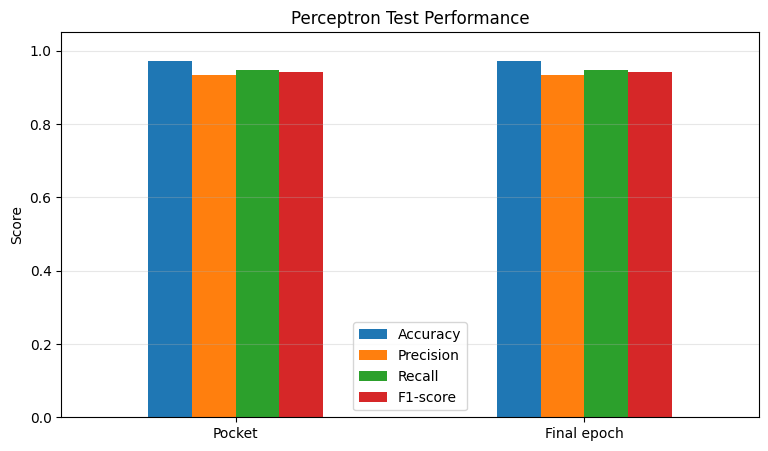


Classification report:
              precision    recall  f1-score   support

     Ham (0)     0.9842    0.9795    0.9819       829
    Spam (1)     0.9333    0.9482    0.9407       251

    accuracy                         0.9722      1080
   macro avg     0.9588    0.9639    0.9613      1080
weighted avg     0.9724    0.9722    0.9723      1080



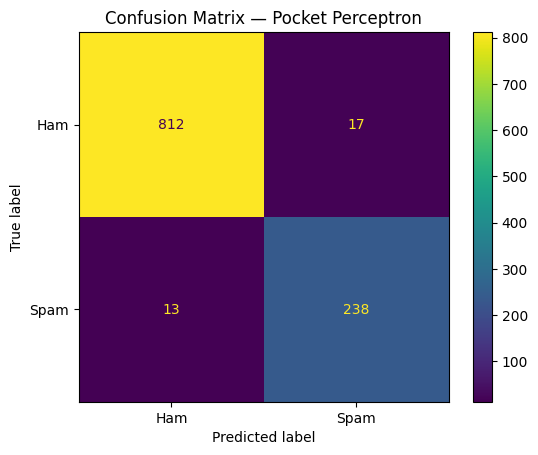

Confusion matrix:
 [[812  17]
 [ 13 238]]
TN: 812  FP: 17  FN: 13  TP: 238


In [38]:
comparison_metrics=pd.DataFrame({"Pocket":pocket_metrics,"Final epoch":final_metrics}).T
comparison_metrics.plot(kind="bar",figsize=(9,5))
plt.title("Perceptron Test Performance"); plt.ylabel("Score"); plt.ylim(0,1.05)
plt.xticks(rotation=0); plt.grid(axis="y",alpha=.3); plt.show()

print("\nClassification report:")
print(classification_report(y_test,y_pred_pocket,target_names=["Ham (0)","Spam (1)"],digits=4,zero_division=0))

cm=confusion_matrix(y_test,y_pred_pocket)
ConfusionMatrixDisplay(cm,display_labels=["Ham","Spam"]).plot()
plt.title("Confusion Matrix — Pocket Perceptron"); plt.show()
print("Confusion matrix:\n",cm)
tn,fp,fn,tp=cm.ravel()
print("TN:",tn," FP:",fp," FN:",fn," TP:",tp)

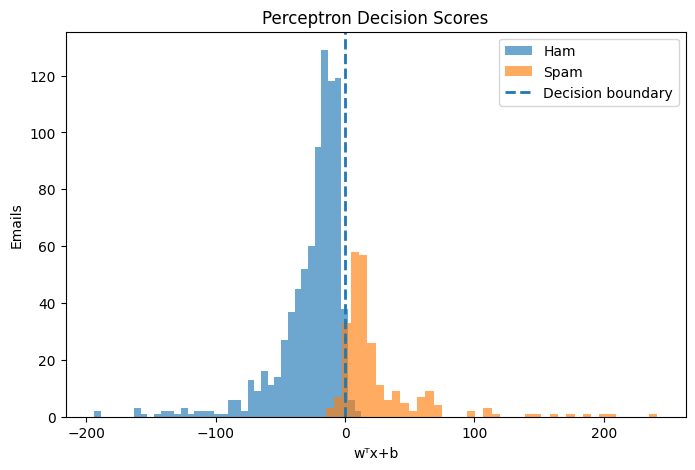

In [39]:
scores=model.decision_function(X_test,use_pocket=True)
plt.figure(figsize=(8,5))
plt.hist(scores[y_test==0],bins=40,alpha=.65,label="Ham")
plt.hist(scores[y_test==1],bins=40,alpha=.65,label="Spam")
plt.axvline(0,linestyle="--",linewidth=2,label="Decision boundary")
plt.title("Perceptron Decision Scores"); plt.xlabel("wᵀx+b"); plt.ylabel("Emails")
plt.legend(); plt.show()

In [40]:
# Misclassified email inspection
test_original=test_raw.select("text","spam").toPandas().reset_index(drop=True)
wrong=y_pred_pocket!=y_test
misclassified=test_original.loc[wrong].copy()
misclassified["Actual"]=y_test[wrong]
misclassified["Predicted"]=y_pred_pocket[wrong]

print("Misclassified test emails:",len(misclassified))
if len(misclassified):
    display(misclassified[["Actual","Predicted","text"]].head(10).assign(text=lambda x:x.text.str[:300]))

Misclassified test emails: 30


,Actual,Predicted,text
52,0,1,Subject: career opportunity dear mr . kaminsk...
73,1,0,Subject: delivery failure : user antonio _ lam...
80,1,0,Subject: digital voice recorders dear sir / m...
84,1,0,Subject: earn 10 k per week with a new system ...
140,0,1,Subject: happy holidays ! i wish you wonderfu...
158,1,0,Subject: i do not have anything against you o...
183,0,1,Subject: introducing the new iijournals online...
185,1,0,Subject: isa article on embedded real - time l...
188,0,1,Subject: it security and standards notice inf...
206,1,0,"Subject: line ? usa today says "" the must hav..."


                    Accuracy  Precision  Recall  F1-score
Manual pocket         0.9722     0.9333  0.9482    0.9407
Manual final epoch    0.9722     0.9333  0.9482    0.9407
scikit-learn          0.9741     0.9588  0.9283    0.9433


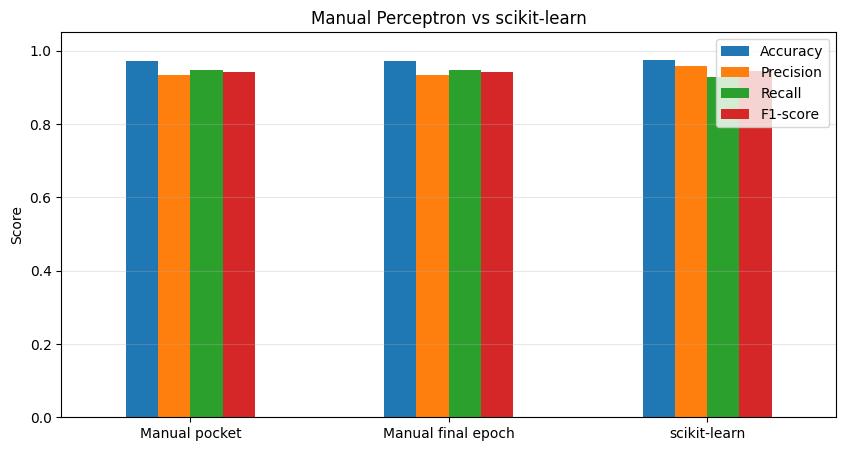

In [42]:
sk_model=SklearnPerceptron(eta0=.01,max_iter=50,tol=None,shuffle=True,random_state=RANDOM_STATE,fit_intercept=True)
sk_model.fit(X_train,y_train_pm)
sk_pred=np.where(sk_model.predict(X_test)==1,1,0)
sk_metrics=metric_summary(y_test,sk_pred)

comparison=pd.DataFrame({
    "Manual pocket":pocket_metrics,
    "Manual final epoch":final_metrics,
    "scikit-learn":sk_metrics
}).T
print(comparison.round(4).to_string())

comparison.plot(kind="bar",figsize=(10,5))
plt.title("Manual Perceptron vs scikit-learn")
plt.ylabel("Score"); plt.ylim(0,1.05); plt.xticks(rotation=0)
plt.grid(axis="y",alpha=.3); plt.show()

In [43]:
print("="*72)
print("PERCEPTRON SPAM EMAIL ASSESSMENT COMPLETED")
print("="*72)
print("Random seed:",RANDOM_STATE)
print("Training observations:",len(X_train))
print("Test observations:",len(X_test))
print("Vocabulary size:",len(cv_model.vocabulary))
print("Feature vector size:",X_train.shape[1])
print("Epochs completed:",len(model.errors_per_epoch_))
print("Converged:",model.converged_)
print("Best training errors:",model.best_errors_)
print("Best epoch:",model.best_epoch_)
print("\nPocket test metrics")
for k,v in pocket_metrics.items(): print(f"{k:10s}: {v:.4f}")
print("="*72)

PERCEPTRON SPAM EMAIL ASSESSMENT COMPLETED
Random seed: 42
Training observations: 4648
Test observations: 1080
Vocabulary size: 5000
Feature vector size: 5000
Epochs completed: 32
Converged: True
Best training errors: 0
Best epoch: 32

Pocket test metrics
Accuracy  : 0.9722
Precision : 0.9333
Recall    : 0.9482
F1-score  : 0.9407


### Summary / Conclusion

The Perceptron algorithm was successfully implemented using PySpark to classify email messages as **spam or non-spam (ham)**. The dataset was loaded into a Spark DataFrame, explored, and prepared for machine learning. Since the provided dataset contains email text, the text was transformed into numerical features using **tokenisation, stop-word removal, CountVectorizer, and TF-IDF**. Feature scaling was then applied before training the Perceptron model.

The Perceptron was implemented as a binary linear classifier, with the model learning weights and a bias through iterative updates based on incorrectly classified training examples. The training process was monitored using the learning curve, and the final model was evaluated on the unseen test dataset.

The performance of the model was assessed using **accuracy, precision, recall, and F1-score**, together with a confusion matrix. These metrics provide a more complete evaluation than accuracy alone, particularly because spam classification requires careful consideration of both false positives and false negatives. The results show how effectively the Perceptron can distinguish spam emails from legitimate emails.

Overall, this assessment demonstrated the complete PySpark machine-learning workflow, from **data loading and preprocessing to feature extraction, model implementation, prediction, and evaluation**. The experiment also showed that the Perceptron provides a simple and interpretable approach to binary spam classification, although its performance depends strongly on the quality of the extracted features and the chosen training parameters.
